# Load MuseGAN Repo from Github


In [14]:
!git clone https://github.com/ltrickey/musegan.git

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GitHub/musegan


**Import libraries**

In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch import nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Models

In [3]:
from gan import TemporalNetwork, BarGenerator, MuseCritic, MuseGenerator

# TempNetwork

In [4]:
tempnet = TemporalNetwork()
x = torch.rand(10, 32)
tempnet(x).shape

torch.Size([10, 32, 2])

In [5]:
print('Number of parameters:', sum(p.numel() for p in tempnet.parameters()))

Number of parameters: 101472


# BarGenerator

In [6]:
bargenerator = BarGenerator()
a = torch.rand(10, 128)
bargenerator(a).shape

torch.Size([10, 1, 1, 16, 84])

In [7]:
print('Number of parameters:', sum(p.numel() for p in bargenerator.parameters()))

Number of parameters: 1517313


# MuseGenerator

In [8]:
generator = MuseGenerator()

cords = torch.rand(10, 32)
style = torch.rand(10, 32)
melody = torch.rand(10, 4, 32)
groove = torch.rand(10, 4, 32)

generator(cords, style, melody, groove).shape

torch.Size([10, 4, 2, 16, 84])

In [9]:
print('Number of parameters:', sum(p.numel() for p in generator.parameters()))

Number of parameters: 6576612


# MuseCritic

In [10]:
critic = MuseCritic()
a = torch.rand(10, 4, 2, 16, 84)
critic(a).shape

torch.Size([10, 1])

In [ ]:
print('Number of parameters:', sum(p.numel() for p in critic.parameters()))

Number of parameters: 1446401


In [11]:
# Install scikit-learn if not already installed
!pip install scikit-learn
# Install HarmonyDagger
!pip install harmonydagger

# Dataset Transformation - Add peturbation with HarmonyDagger

In [13]:
from torch.utils.data import DataLoader
from data.utils import MidiDataset
from harmonydagger.file_operations import parallel_batch_process, recursive_find_audio_files


dataset = MidiDataset(path='data/chorales/Jsb16thSeparated.npz')



# data = np.load('yourfile.npz')
# array = data['arr_0']  # Replace 'arr_0' with the actual key
# split_index = int(len(array) * 0.15)
# array1 = array[:split_index]
# array2 = array[split_index:]

# # Find all audio files in a directory (supports MP3, FLAC, OGG, and WAV)
# audio_files = recursive_find_audio_files('./audio_files')

# # Or specify only specific formats
# # audio_files = recursive_find_audio_files('./audio_files', extensions=['.mp3', '.flac'])

# # Process files in parallel
# results = parallel_batch_process(
#     audio_files,
#     output_dir='./protected_audio',
#     window_size=2048,
#     hop_size=512,
#     noise_scale=0.1,
#     adaptive_scaling=True,
#     max_workers=4  # Use 4 CPU cores
# )

# # Print results
# for file_path, result in results.items():
#     if result['success']:
#         print(f"Successfully processed {file_path} in {result['processing_time']:.2f} seconds")
#     else:
#         print(f"Failed to process {file_path}: {result['error']}")


# dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

# Define Models

### Generator

In [ ]:
generator = MuseGenerator(z_dimension=32, hid_channels=1024, hid_features=1024, out_channels=1).to(device)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001, betas=(0.5, 0.9))

### Critic

In [ ]:
critic = MuseCritic(hid_channels=128,
                    hid_features=1024,
                    out_features=1).to(device)
c_optimizer = torch.optim.Adam(critic.parameters(), lr=0.001, betas=(0.5, 0.9))

In [ ]:
from gan import initialize_weights

generator = generator.apply(initialize_weights)
critic = critic.apply(initialize_weights)

# Training

In [ ]:
from trainer import Trainer

In [ ]:
trainer = Trainer(generator, critic, g_optimizer, c_optimizer)

In [ ]:
trainer.train(dataloader, epochs=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/1000 | Generator loss: -34.497 | Critic loss: -144.339
(fake: 86.333, real: -364.606, penalty: 133.934)
Epoch 10/1000 | Generator loss: 1142.958 | Critic loss: -170.488
(fake: -1171.540, real: 890.856, penalty: 110.195)
Epoch 20/1000 | Generator loss: 1244.480 | Critic loss: -27.484
(fake: -897.035, real: 859.719, penalty: 9.832)
Epoch 30/1000 | Generator loss: 979.610 | Critic loss: -21.392
(fake: -974.130, real: 945.965, penalty: 6.773)
Epoch 40/1000 | Generator loss: 978.729 | Critic loss: -15.286
(fake: -661.193, real: 641.867, penalty: 4.040)
Epoch 50/1000 | Generator loss: 141.481 | Critic loss: -10.389
(fake: -467.439, real: 454.523, penalty: 2.527)
Epoch 60/1000 | Generator loss: -269.017 | Critic loss: -9.310
(fake: 355.792, real: -367.347, penalty: 2.245)
Epoch 70/1000 | Generator loss: 35.431 | Critic loss: -17.499
(fake: 0.098, real: -22.343, penalty: 4.746)
Epoch 80/1000 | Generator loss: -83.042 | Critic loss: -21.558
(fake: 74.886, real: -103.626, penalty: 7.182)

In [1]:
losses = trainer.data.copy()

NameError: name 'trainer' is not defined

### Save losses

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict(losses)
#df.to_csv('results.csv', index=False)

### Save models

In [ ]:
# generator = generator.eval().cpu()
# critic = critic.eval().cpu()
#torch.save(generator, 'generator_e1000.pt')
#torch.save(critic, 'critic_e1000.pt')

### Plot losses

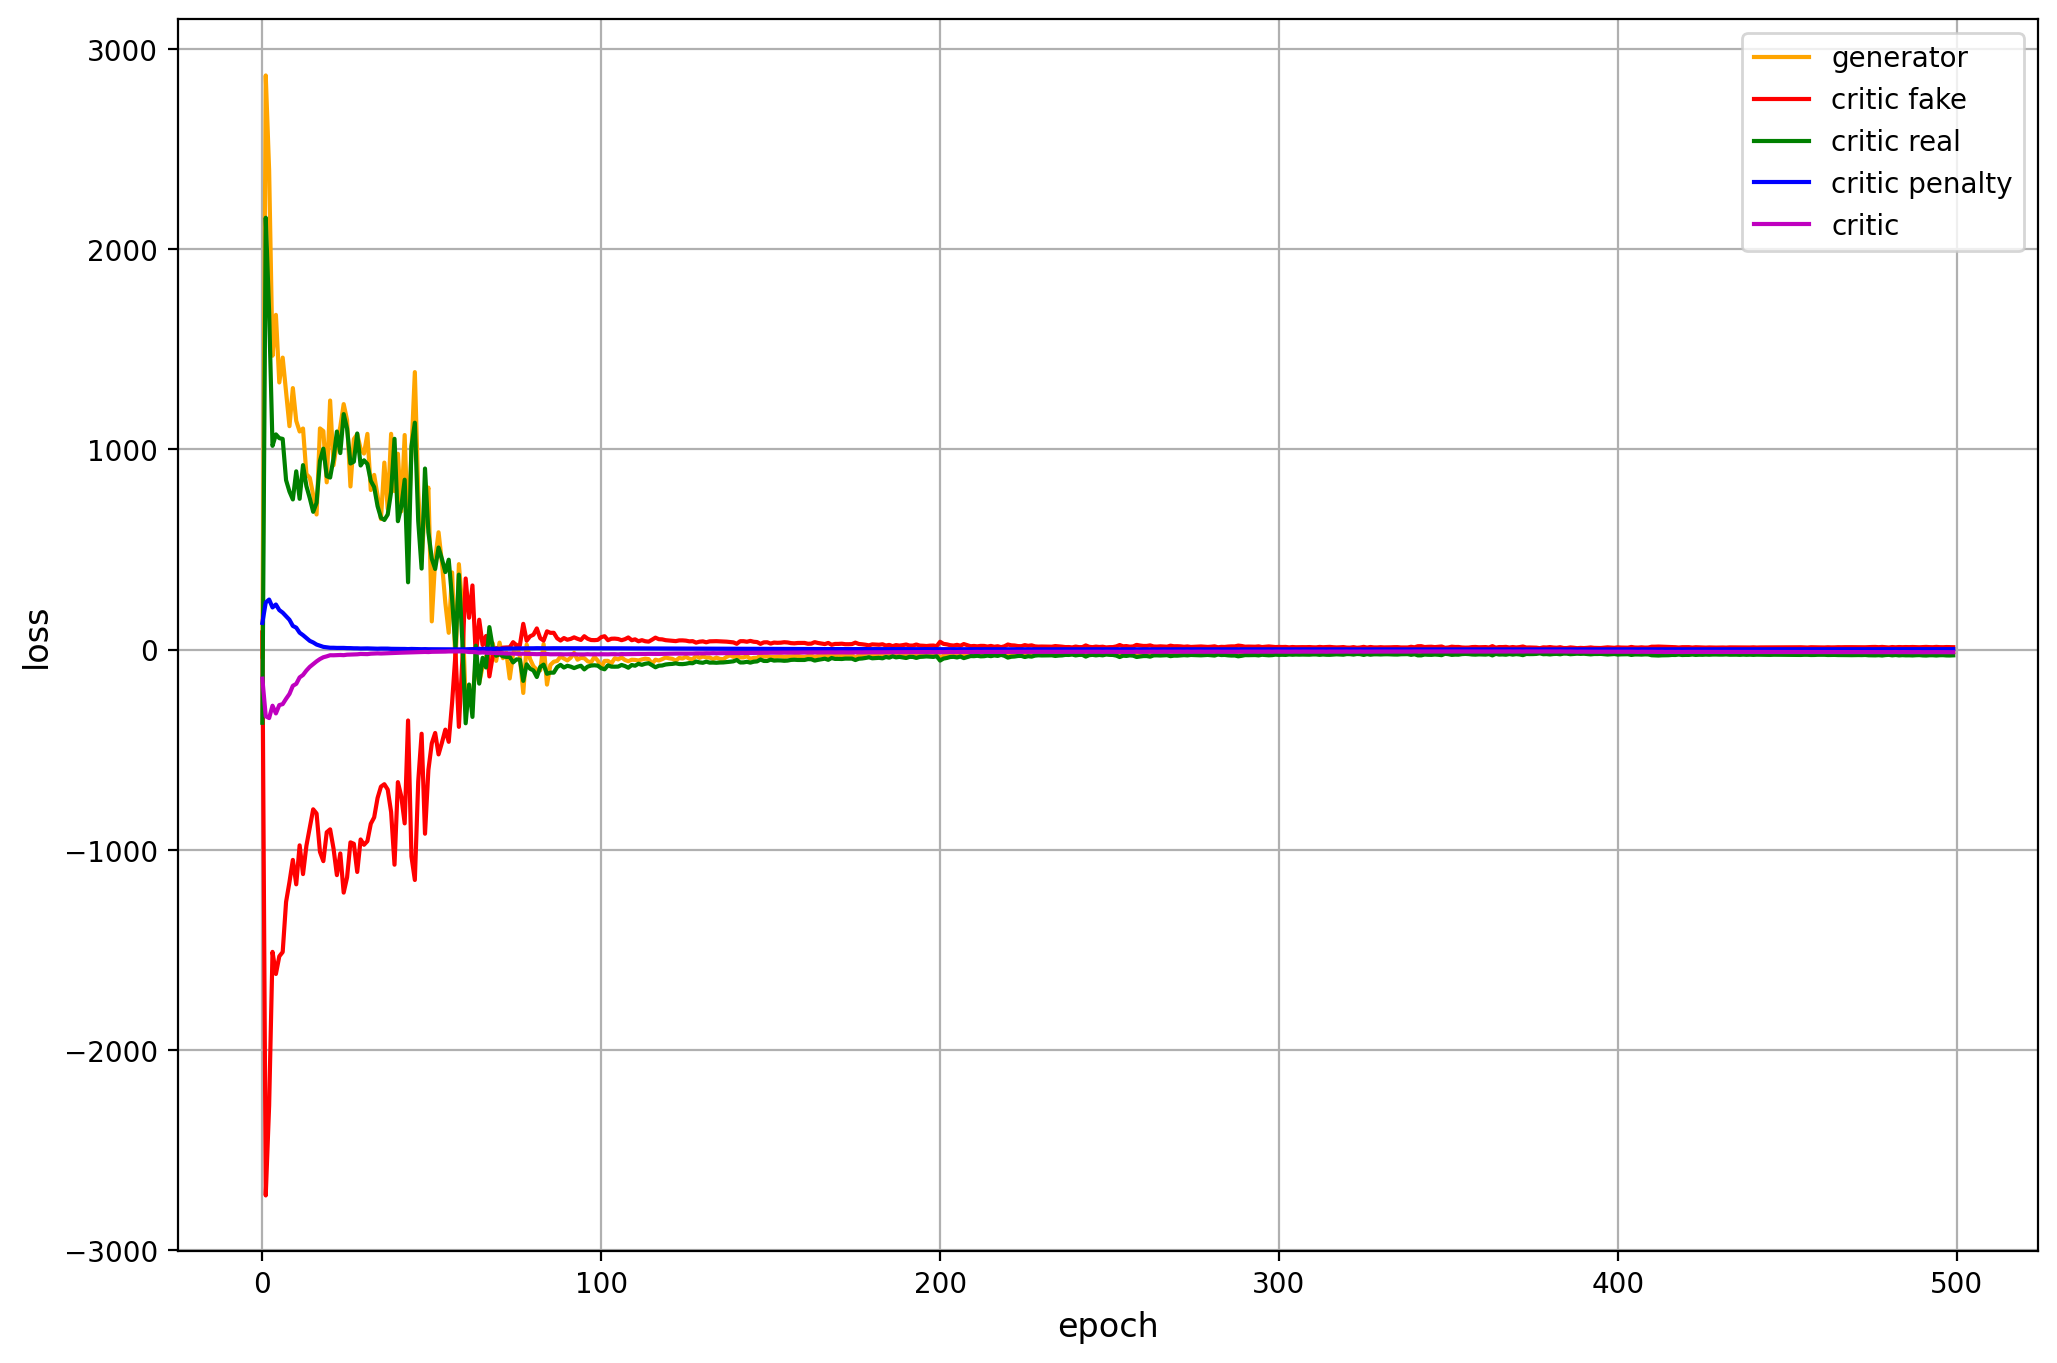

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(losses['gloss'][:500], 'orange', label='generator')
plt.plot(losses['cfloss'][:500], 'r', label='critic fake')
plt.plot(losses['crloss'][:500], 'g', label='critic real')
plt.plot(losses['cploss'][:500], 'b', label='critic penalty')
plt.plot(losses['closs'][:500], 'm', label='critic')
plt.xlabel('epoch', fontsize=12)
plt.ylabel('loss', fontsize=12)
plt.grid()
plt.legend()
plt.show()
#plt.savefig('losses.png')

In [ ]:
generator = generator.eval().cpu()
#generator = torch.load('generator_e1000.pt')

## Make prediction

In [ ]:
chords = torch.rand(1, 32)
style = torch.rand(1, 32)
melody = torch.rand(1, 4, 32)
groove = torch.rand(1, 4, 32)

preds = generator(chords, style, melody, groove).detach()

### Get music data

In [ ]:
from data.utils import postprocess

preds = preds.numpy()
music_data = postprocess(preds)

### Save file

In [ ]:
filename = 'myexample_2.midi'
music_data.write('midi', fp=filename)

'myexample_2.midi'

In [5]:
!apt install fluidsynth
!cp /usr/share/sounds/sf2/FluidR3_GM.sf2 ./font.sf2
!fluidsynth -ni font.sf2 /content/drive/MyDrive/GitHub/musegan/myexample_2.midi -F /content/drive/MyDrive/GitHub/musegan/myexample_2.wav -r 44100


from IPython.display import Audio
Audio('/content/drive/MyDrive/GitHub/musegan/myexampl_1.wav', rate=44100)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file '/content/drive/MyDrive/GitHub/musegan/myexampl_1.wav'..


Play output

First, install FluidSynth and a suitable soundfont. In Google Colab, you can do this by running the following commands: